## Extract the generic MNIST dataset with only digit 3 and 4

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
dataset = pd.read_csv('./data.csv') 

data = np.array(dataset) # conversion from array to ndarray

# data = label | [...features...]
X = data[:, 1:].T   # extract features  
Y = data[:, 0]      # extract labels    

print(X.shape, Y.shape)

(784, 42000) (42000,)


In [4]:
idxs = np.where((Y == 3) | (Y == 4))[0]
X = X[:, idxs]
Y = Y[idxs]

In [ ]:
def train_test_split (X, Y, N, perc) :
    idx = np.arange(0, N)
    np.random.shuffle(idx)

    idx_train = int(perc*N)

    train_idx = idx[:idx_train]
    test_idx = idx[idx_train:]

    X_train = X[:, train_idx]
    Y_train = Y[train_idx]

    X_test = X[:, test_idx]
    Y_test = Y[test_idx]
    return X_train, X_test, Y_train, Y_test

def experiment(U1, U2, X, Y, C1, C2) :
    misclassifications = 0
    
    for i in range(Y.shape[0]) :
        y = X[:, i]
        y1 = U1 @ (U1.T @ y)
        y2 = U2 @ (U2.T @ y)
        d1 = np.linalg.norm(y - y1, 2)
        d2 = np.linalg.norm(y - y2, 2)
        if (d1 < d2) & (Y[i] == C2):
            misclassifications += 1
        elif (d1 > d2) & (Y[i] == C1):
            misclassifications += 1
            
    return misclassifications/Y.shape[0] * 100.0

## Compute the experiment with respect to a parametric `train_size` with many points all over the range $[0,1]$

In [ ]:
train_sizes = np.linspace(0.01, 0.95, 200)
missclassification_train, missclassification_test = [], []

for train_size in train_sizes:
    print("="*50)
    print(f"Train size: {train_size}")
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, X.shape[1], train_size)
    print(X_train.shape, X_test.shape)
    print(Y_train.shape, Y_test.shape)
    
    # They are already flatten
    X1 = X_train[:, (Y_train == 3)]
    X2 = X_train[:, (Y_train == 4)]
    print(X1.shape, X2.shape)
    
    U1, s1, VT1 = np.linalg.svd(X1, full_matrices = False)
    U2, s2, VT2 = np.linalg.svd(X2, full_matrices = False)
    
    # Compute misclassification for train set
    mis_train = experiment(U1, U2, X_train, Y_train, 3, 4)
    print(f"The missclassification for train set is {mis_train}%")

    # Compute misclassification for test set
    mis_test = experiment(U1, U2, X_test, Y_test, 3, 4)
    print(f"The missclassification for test set is {mis_test}%")
    
    missclassification_test.append(mis_test)
    missclassification_train.append(mis_train)

Train size: 0.01
(784, 84) (784, 8339)
(84,) (8339,)
(784, 49) (784, 35)
The missclassification for train set is 0.0%
The missclassification for test set is 0.7195107327017628%
Train size: 0.014723618090452261
(784, 124) (784, 8299)
(124,) (8299,)
(784, 60) (784, 64)
The missclassification for train set is 0.0%
The missclassification for test set is 0.4940354259549343%
Train size: 0.01944723618090452
(784, 163) (784, 8260)
(163,) (8260,)
(784, 80) (784, 83)
The missclassification for train set is 0.0%
The missclassification for test set is 0.5811138014527845%
Train size: 0.024170854271356783
(784, 203) (784, 8220)
(203,) (8220,)
(784, 108) (784, 95)
The missclassification for train set is 0.0%
The missclassification for test set is 0.413625304136253%
Train size: 0.028894472361809045
(784, 243) (784, 8180)
(243,) (8180,)
(784, 138) (784, 105)
The missclassification for train set is 0.0%
The missclassification for test set is 0.6601466992665036%
Train size: 0.03361809045226131
(784, 283)

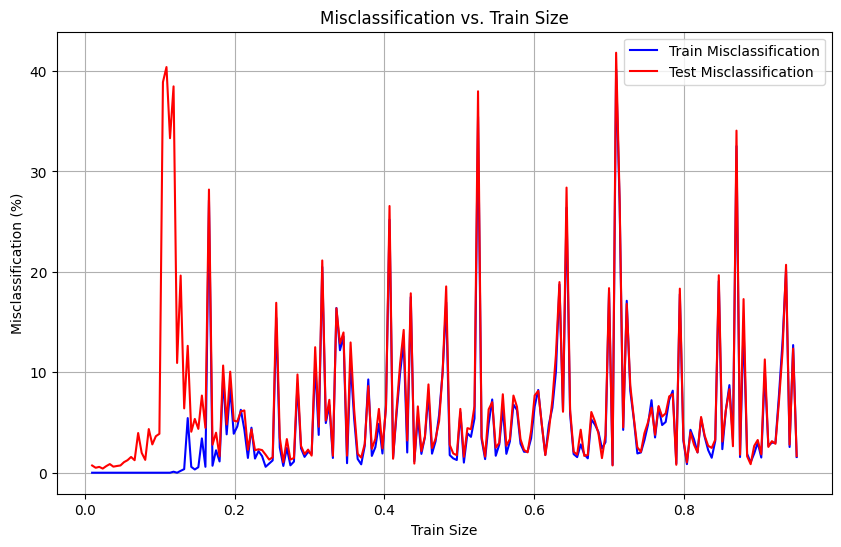

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, missclassification_train, label="Train Misclassification", color="blue")
plt.plot(train_sizes, missclassification_test, label="Test Misclassification", color="red")
plt.xlabel("Train Size")
plt.ylabel("Misclassification (%)")
plt.title("Misclassification vs. Train Size")
plt.legend()
plt.grid()
plt.show()

As we expected from a stochastic train/test split procedure, the misclassification rate is noisy with respect to the training size, except for the range $[0,10]$%, where we can find a not-too-much noisy behaviour that suggest a pattern, moreover we instead expected to find the highest values of misclassification since the training size is at its lowest and the test size is the biggest, instead the misclassification is the lowest of the plot.


Now we want to understand if this is an exception or if it is a feature of the dataset, we will check this by running many experiments all over the data (we will consider only the 0-10% window of training size)

## Repeat the entire experiment N times (at the beginning)

In [6]:
import numpy as np
from tqdm import tqdm
results = []

# Use the exacy num of points that i had before in the interval [0.01, 0.1]
new_start = 0.01
new_end = 0.1
train_sizes = np.linspace(0.01, 0.95, 200)
new_num_points = len(train_sizes[(train_sizes >= 0.01) & (train_sizes <= 0.1)])

for iteration in tqdm(range(1, 101), desc="Test numbers"):

    train_sizes = np.linspace(new_start, new_end, new_num_points)
    missclassifications_train, missclassifications_test = [], []

    for train_size in train_sizes:
        X_train, X_test, Y_train, Y_test = train_test_split(X, Y, X.shape[1], train_size)
        
        # They are already flatten
        X1 = X_train[:, (Y_train == 3)]
        X2 = X_train[:, (Y_train == 4)]
        
        U1, s1, VT1 = np.linalg.svd(X1, full_matrices = False)
        U2, s2, VT2 = np.linalg.svd(X2, full_matrices = False)
        
        # Compute misclassification for train set
        mis_train = experiment(U1, U2, X_train, Y_train, 3, 4)

        # Compute misclassification for test set
        mis_test = experiment(U1, U2, X_test, Y_test, 3, 4)
        
        missclassifications_test.append(mis_test)
        missclassifications_train.append(mis_train)
    
    results. append((missclassifications_train, missclassifications_test))

Test numbers: 100%|██████████| 100/100 [1:45:42<00:00, 63.43s/it]  


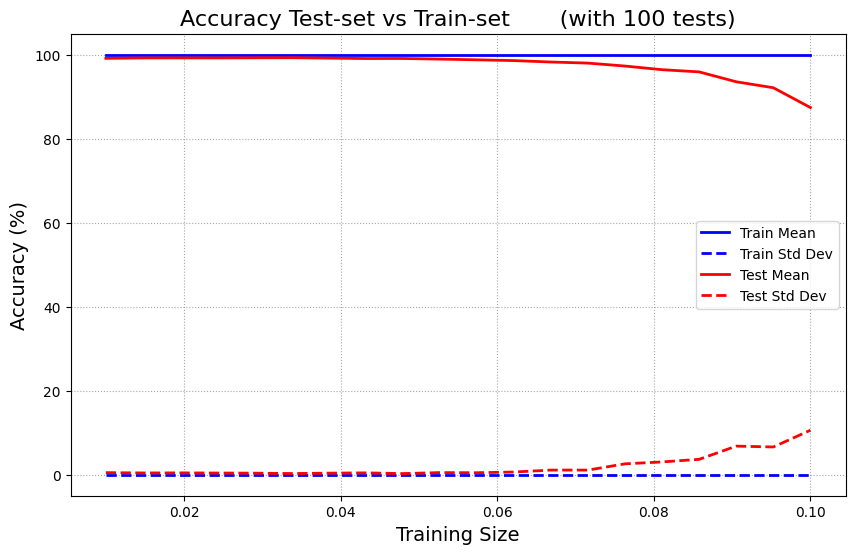

In [14]:
new_train_sizes = np.linspace(new_start, new_end, new_num_points)

missclassifications_train_mean = np.mean([[100-e for e in E[0]] for E in results], axis=0)
missclassifications_train_std = np.std([[100-e for e in E[0]] for E in results], axis=0)
missclassifications_test_mean = np.mean([[100-e for e in E[1]] for E in results], axis=0)
missclassifications_test_std = np.std([[100-e for e in E[1]] for E in results], axis=0)

plt.figure(figsize=(10, 6))

plt.plot(new_train_sizes, missclassifications_train_mean, label='Train Mean', color='blue', linestyle='-', linewidth=2)
plt.plot(new_train_sizes, missclassifications_train_std, label='Train Std Dev', color='blue', linestyle='--', linewidth=2)
plt.plot(new_train_sizes, missclassifications_test_mean, label='Test Mean', color='red', linestyle='-', linewidth=2)
plt.plot(new_train_sizes, missclassifications_test_std, label='Test Std Dev', color='red', linestyle='--', linewidth=2)

plt.title(f'Accuracy Test-set vs Train-set       (with {len(results)} tests)', fontsize=16)
plt.xlabel('Training Size', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=14)

plt.grid(True, linestyle=':', color='gray', alpha=0.7)

plt.legend()

# plt.tight_layout()
plt.show()


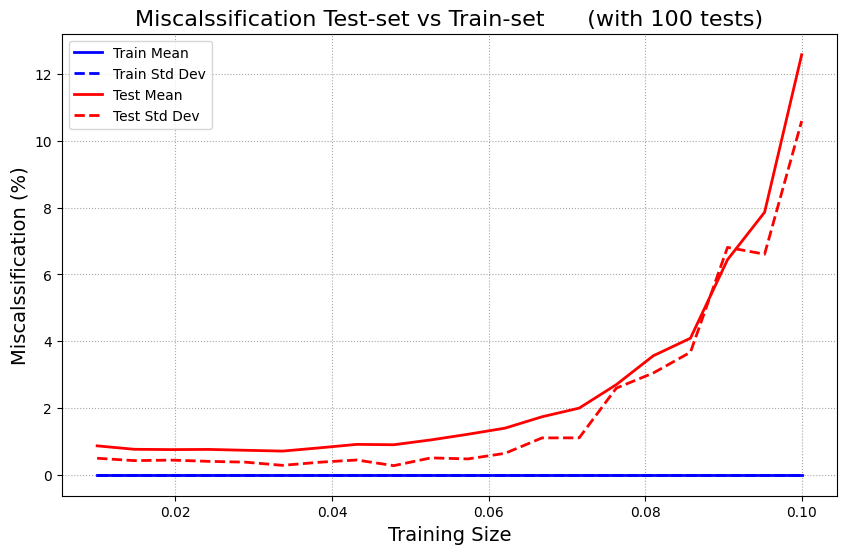

In [ ]:
# Same code but with accuracy=(100-misclassification)

new_train_sizes = np.linspace(new_start, new_end, new_num_points)

missclassifications_train_mean = np.mean([E[0] for E in results], axis=0)
missclassifications_train_std = np.std([E[0] for E in results], axis=0)
missclassifications_test_mean = np.mean([E[1] for E in results], axis=0)
missclassifications_test_std = np.std([E[1] for E in results], axis=0)

plt.figure(figsize=(10, 6))

plt.plot(new_train_sizes, missclassifications_train_mean, label='Train Mean', color='blue', linestyle='-', linewidth=2)
plt.plot(new_train_sizes, missclassifications_train_std, label='Train Std Dev', color='blue', linestyle='--', linewidth=2)
plt.plot(new_train_sizes, missclassifications_test_mean, label='Test Mean', color='red', linestyle='-', linewidth=2)
plt.plot(new_train_sizes, missclassifications_test_std, label='Test Std Dev', color='red', linestyle='--', linewidth=2)

plt.title(f'Miscalssification Test-set vs Train-set      (with {len(results)} tests)', fontsize=16)
plt.xlabel('Training Size', fontsize=14)
plt.ylabel('Miscalssification (%)', fontsize=14)

plt.grid(True, linestyle=':', color='gray', alpha=0.7)

plt.legend()

# plt.tight_layout()
plt.show()
